In [ ]:
# Essential imports
import os
import re
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf pix2pix_dataset
!unzip /content/drive/MyDrive/MRI/pix2pix_dataset.zip

Archive:  /content/drive/MyDrive/MRI/pix2pix_dataset.zip
   creating: pix2pix_dataset/
   creating: pix2pix_dataset/train/
   creating: pix2pix_dataset/train/A/
  inflating: pix2pix_dataset/train/A/patient0_aligned_000.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_001.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_002.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_003.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_004.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_007.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_010.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_011.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_012.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_014.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_015.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_016.jpg  
  inflating: pix2pix_dataset/train/A/patient0_aligned_017.jpg  
  infla

In [ ]:
train_A_path = 'pix2pix_dataset/train/A'
train_B_path = 'pix2pix_dataset/train/B'
val_A_path = 'pix2pix_dataset/val/A'
val_B_path = 'pix2pix_dataset/val/B'

In [ ]:
def extract_patient_number(filename):
    match = re.match(r'patient(\d+)', filename)
    return int(match.group(1)) if match else None

In [ ]:
class PatientDataset(Dataset):
    def __init__(self, path_A, path_B, transform=None):
        self.transform = transform
        self.pairs = []

        # Group files by patient number
        a_files = defaultdict(list)
        b_files = defaultdict(list)

        # Process A directory
        for fname in sorted(os.listdir(path_A)):
            patient = extract_patient_number(fname)
            if patient is not None:
                a_files[patient].append(os.path.join(path_A, fname))

        # Process B directory
        for fname in sorted(os.listdir(path_B)):
            patient = extract_patient_number(fname)
            if patient is not None:
                b_files[patient].append(os.path.join(path_B, fname))

        # Create pairs for common patients
        common_patients = set(a_files.keys()) & set(b_files.keys())
        for patient in common_patients:
            a_imgs = sorted(a_files[patient])
            b_imgs = sorted(b_files[patient])

            # Pair images sequentially within patient
            min_count = min(len(a_imgs), len(b_imgs))
            if len(a_imgs) != len(b_imgs):
                warnings.warn(f"Patient {patient}: Using {min_count} pairs (A: {len(a_imgs)}, B: {len(b_imgs)})")

            self.pairs.extend(zip(a_imgs[:min_count], b_imgs[:min_count]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        a_path, b_path = self.pairs[idx]

        img_A = Image.open(a_path).convert('RGB')
        img_B = Image.open(b_path).convert('RGB')

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        return {'A': img_A, 'B': img_B}

# Usage remains the same as previous
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
train_dataset = PatientDataset(train_A_path, train_B_path, transform=transform)
val_dataset = PatientDataset(val_A_path, val_B_path, transform=transform)


In [ ]:
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
print(f"Total training pairs: {len(train_dataset)}")
print(f"Total validation pairs: {len(val_dataset)}")


Total training pairs: 1500
Total validation pairs: 500


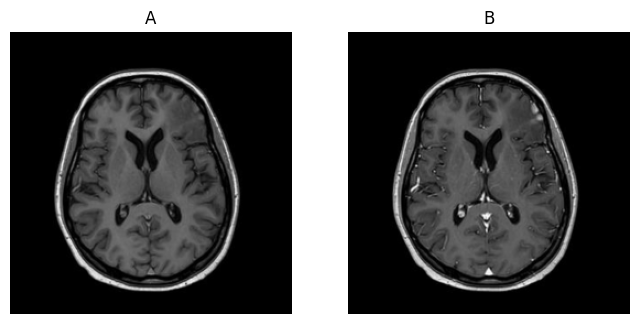

In [ ]:
sample = train_dataset[100]
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample['A'].permute(1, 2, 0) * 0.5 + 0.5)
plt.title('A')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample['B'].permute(1, 2, 0) * 0.5 + 0.5)
plt.title('B')
plt.axis('off')
plt.show()

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image
# Define the Generator (U-Net)
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsampling
        self.down1 = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2)
        )
        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )

        # Upsampling
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        # Implement U-Net with skip connections
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)

        u1 = self.up1(d3)
        u1 = torch.cat([u1, d2], 1)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], 1)
        u3 = self.up3(u2)
        return u3

In [ ]:
# Define the Discriminator (PatchGAN)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        return self.model(torch.cat([x, y], 1))

In [ ]:
# Initialize models
device = torch.device('cuda')
generator = UNetGenerator().to(device)
discriminator = Discriminator().to(device)

# Loss functions and optimizers
criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training parameters
num_epochs = 60
lambda_L1 = 100  # Weight for L1 loss


In [ ]:
best_loss_G = 100
# Training loop
for epoch in range(num_epochs):
    for i, batch in enumerate(train_loader):
        # Move data to device
        real_A = batch['A'].to(device)  # Input images
        real_B = batch['B'].to(device)  # Target images

        # Train Discriminator
        optimizer_D.zero_grad()

        # Generate fake image
        fake_B = generator(real_A)

        # Real loss
        pred_real = discriminator(real_B, real_A)
        loss_real = criterion_GAN(pred_real, torch.ones_like(pred_real))

        # Fake loss
        pred_fake = discriminator(fake_B.detach(), real_A)
        loss_fake = criterion_GAN(pred_fake, torch.zeros_like(pred_fake))

        # Total discriminator loss
        loss_D = (loss_real + loss_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        # Adversarial loss
        pred_fake = discriminator(fake_B, real_A)
        loss_GAN = criterion_GAN(pred_fake, torch.ones_like(pred_fake))

        # L1 loss
        loss_L1 = criterion_L1(fake_B, real_B) * lambda_L1

        # Total generator loss
        loss_G = loss_GAN + loss_L1
        loss_G.backward()
        optimizer_G.step()

        # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss D: {loss_D.item():.4f} Loss G: {loss_G.item():.4f}")
    if loss_G.item() <= best_loss_G:
        best_loss_G = loss_G.item()
        torch.save(generator.state_dict(), 'best_generator.pth')
        print("Saved best model!")

    # Save model checkpoints
    if (epoch+1) % 10 == 0:
        torch.save(generator.state_dict(), f'generator_epoch_{epoch+1}.pth')
        torch.save(discriminator.state_dict(), f'discriminator_epoch_{epoch+1}.pth')


    # Save sample images
    with torch.no_grad():
        fake = generator(real_A[:1])
        img_sample = torch.cat([real_A[:1], fake, real_B[:1]], -1)
        save_image(img_sample, f"epoch_{epoch+1}_train_sample.png", normalize=True)

Epoch [1/60] Loss D: 0.4593 Loss G: 6.2872
Saved best model!
Epoch [2/60] Loss D: 0.9550 Loss G: 4.8707
Saved best model!
Epoch [3/60] Loss D: 0.5614 Loss G: 4.4888
Saved best model!
Epoch [4/60] Loss D: 0.4172 Loss G: 7.0952
Epoch [5/60] Loss D: 0.5029 Loss G: 5.7847
Epoch [6/60] Loss D: 0.3351 Loss G: 6.3750
Epoch [7/60] Loss D: 0.3852 Loss G: 6.4163
Epoch [8/60] Loss D: 0.2620 Loss G: 6.2465
Epoch [9/60] Loss D: 0.2228 Loss G: 6.8097
Epoch [10/60] Loss D: 0.6991 Loss G: 4.9611
Epoch [11/60] Loss D: 0.3795 Loss G: 6.4969
Epoch [12/60] Loss D: 0.4875 Loss G: 8.1261
Epoch [13/60] Loss D: 0.5388 Loss G: 6.2438
Epoch [14/60] Loss D: 0.2526 Loss G: 6.6897
Epoch [15/60] Loss D: 0.3769 Loss G: 5.8032
Epoch [16/60] Loss D: 0.5518 Loss G: 5.7860
Epoch [17/60] Loss D: 0.5815 Loss G: 5.2466
Epoch [18/60] Loss D: 0.3462 Loss G: 9.2261
Epoch [19/60] Loss D: 0.4738 Loss G: 5.1935
Epoch [20/60] Loss D: 0.4818 Loss G: 6.6234
Epoch [21/60] Loss D: 0.6125 Loss G: 4.5435
Epoch [22/60] Loss D: 0.4162 Lo

In [ ]:
torch.save(generator.state_dict(), 'generator_final.pth')
!cp generator_final.pth /content/drive/MyDrive/MRI/generator_best.pth
!cp generator_final.pth /content/drive/MyDrive/MRI/generator_final.pth

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

generator = UNetGenerator().to(device)
generator.load_state_dict(
    torch.load('/content/drive/MyDrive/MRI/generator_final.pth',
             map_location=device)
)
generator.eval()

avg_SSIM = 0
count_SSIM = 0
max_SSIM = 0
max_SSIM_index = 0

with torch.no_grad():
    for val_batch in val_loader:
        real_A = val_batch['A'].to(device)
        real_B = val_batch['B'].to(device)
        fake_B = generator(real_A)

        # Convert to numpy arrays
        real_A_np = real_A.cpu().numpy().transpose(0, 2, 3, 1)
        real_B_np = real_B.cpu().numpy().transpose(0, 2, 3, 1)  # (B, H, W, C)
        fake_B_np = fake_B.cpu().numpy().transpose(0, 2, 3, 1)

        # Denormalize to [0, 1]
        real_B_np = (real_B_np * 0.5 + 0.5).astype(np.float64)
        fake_B_np = (fake_B_np * 0.5 + 0.5).astype(np.float64)

        # Calculate SSIM per image
        for i in range(real_B_np.shape[0]):
            # Auto-calculate safe window size
            h, w, _ = real_B_np[i].shape
            win_size = min(7, h, w)
            win_size = win_size if win_size % 2 == 1 else win_size - 1

            current_ssim = ssim(
                real_B_np[i],
                fake_B_np[i],
                win_size=win_size,
                channel_axis=2,  # For color images
                data_range=1.0
            )
            avg_SSIM += current_ssim
            count_SSIM += 1
            if max_SSIM <= current_ssim:
              max_SSIM = current_ssim
              max_SSIM_index = count_SSIM
            with torch.no_grad():
              img_sample = torch.cat([real_A[i], real_B[i], fake_B[i]], -1)
              save_image(img_sample, f"output/sample_{count_SSIM}.png", normalize=True)

print(f"Average SSIM: {avg_SSIM/count_SSIM:.4f}")
print(f"Max SSIM: {max_SSIM:.4f}")
print(f"Max SSIM index: {max_SSIM_index}")

<ipython-input-50-61619409bed1>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load('/content/drive/MyDrive/MRI/generator_final.pth',


Average SSIM: 0.8615
Max SSIM: 0.9857
Max SSIM index: 155


In [ ]:
!mkdir /content/drive/MyDrive/MRI/output_final_generator/

In [ ]:
!cp -a output/. /content/drive/MyDrive/MRI/output_final_generator/